Task 3: Car Price Prediction with Machine Learning

R2 Score: 0.9356015179552569
MAE: 95923.96853713915


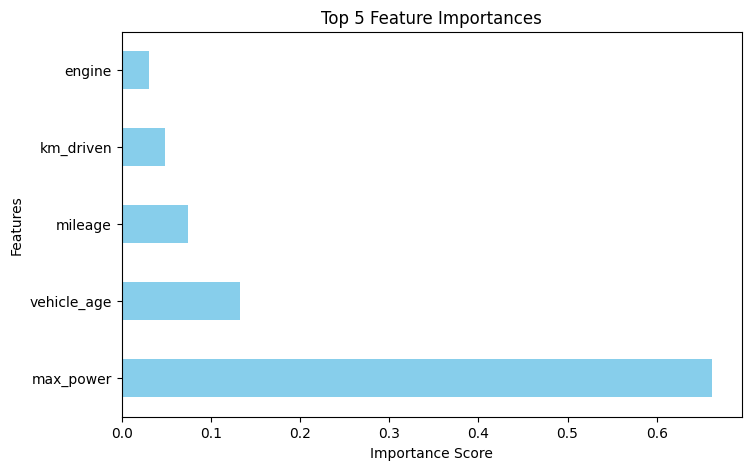

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Load Data
df = pd.read_csv('cardekho_dataset.csv')
df.dropna(inplace=True)

# 2. Smart Feature Engineering (Automatically handles text and year columns)
for col in df.select_dtypes(include=['object']).columns:
    if 'name' in col.lower() or 'car' in col.lower():
        # Car ke naam se brand nikal kar naya column bana lo aur purana naam wala column drop kar do
        df['Brand'] = df[col].apply(lambda x: str(x).split()[0])
        df.drop(columns=[col], inplace=True, errors='ignore')

# Year column ko dhoond kar Car_Age calculate karna
year_col = next((c for c in df.columns if 'year' in c.lower()), None)
if year_col:
    df['Car_Age'] = 2026 - df[year_col]
    df.drop(columns=[year_col], inplace=True, errors='ignore')

# 3. Automatically Encode ALL remaining text/categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# 4. Target column ko automatically detect karna ('selling_price' ya 'Price' etc.)
target_col = next((c for c in df.columns if 'price' in c.lower()), None)
if target_col is None:
    target_col = df.columns[-1]  # Agar koi na mile toh aakhri column target maan lo

# 5. Train/Test Split
X = df.drop(target_col, axis=1)
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Model Training (Random Forest Regressor)
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# 7. Evaluation Metrics
print("R2 Score:", r2_score(y_test, rf_preds))
print("MAE:", mean_absolute_error(y_test, rf_preds))

# 8. Feature Importance Visualization
importances = pd.Series(rf.feature_importances_, index=X.columns)
plt.figure(figsize=(8, 5))
importances.nlargest(5).plot(kind='barh', color='skyblue')
plt.title('Top 5 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()